# Ramsey-Cass-Koopmans Model (Discrete Time)

**Final Project Starter**

The Ramsey (1928), Cass (1965), and Koopmans (1965) model with CRRA utility and partial depreciation. Unlike Brock-Mirman, there is no analytical solution; the transition dynamics require solving a saddle-path problem numerically via shooting.

All variables are in per-efficiency-unit terms: $k_t = K_t / (A_t L_t)$, $c_t = C_t / (A_t L_t)$, where $K_t$ is capital, $A_t$ is labor-augmenting productivity growing at rate $g$, and $L_t$ is population growing at rate $n$.

The planner maximizes CRRA utility with coefficient of relative risk aversion $\rho$ and discount factor $\beta$, over per-capita consumption $C_t/L_t = A_t c_t$. Capital depreciates at rate $\delta$:

$$\max \sum_{t=0}^{\infty} \beta^t \frac{(A_t c_t)^{1-\rho}}{1-\rho}.$$

Since $A_t = A_0 (1+g)^t$, the effective discount factor on $c_t^{1-\rho}$ is $\beta(1+g)^{1-\rho}$ per period.

The Euler equation in per-efficiency-unit terms is

$$\frac{c_{t+1}}{c_t} = \frac{\left(\beta(f'(k_{t+1}) + 1 - \delta)\right)^{1/\rho}}{(1+g)(1+n)^{1/\rho}}.$$

The $(1+g)$ in the denominator converts from per-capita to per-efficiency-unit growth. The $(1+n)^{1/\rho}$ arises because the resource constraint divides by $(1+g)(1+n)$, which raises the shadow price of capital and slows consumption growth.

The resource constraint in exact discrete time is

$$k_{t+1} = \frac{f(k_t) + (1-\delta)k_t - c_t}{(1+g)(1+n)}.$$

At steady state, $f'(k^*) + 1 - \delta = (1+g)^\rho (1+n)/\beta$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## Calibration and Steady State

In [2]:
# Parameters
alpha = 0.33    # capital share
beta = 0.96     # discount factor (on per-capita utility)
rho = 2.0       # CRRA coefficient
delta = 0.10    # depreciation
n = 0.01        # population growth
g = 0.02        # productivity growth

def f(k):
    return k ** alpha

def f_prime(k):
    return alpha * k ** (alpha - 1)

# Steady state: f'(k*) + 1 - delta = (1+g)^rho * (1+n) / beta
R_ss = (1 + g) ** rho * (1 + n) / beta
mpk_ss = R_ss - 1 + delta
k_ss = (alpha / mpk_ss) ** (1 / (1 - alpha))

# From resource constraint at SS: k = (f(k) + (1-delta)*k - c) / ((1+g)*(1+n))
# => c_ss = f(k_ss) + (1-delta)*k_ss - (1+g)*(1+n)*k_ss
c_ss = f(k_ss) + (1 - delta) * k_ss - (1 + g) * (1 + n) * k_ss
y_ss = f(k_ss)

# Golden rule: f'(k_gr) = (1+g)*(1+n) - 1 + delta
mpk_gr = (1 + g) * (1 + n) - 1 + delta
k_gr = (alpha / mpk_gr) ** (1 / (1 - alpha))
c_gr = f(k_gr) + (1 - delta) * k_gr - (1 + g) * (1 + n) * k_gr

print(f"Steady state: k* = {k_ss:.4f}, c* = {c_ss:.4f}, y* = {y_ss:.4f}")
print(f"Golden rule:  k_gr = {k_gr:.4f}, c_gr = {c_gr:.4f}")
print(f"Dynamic efficiency: k* < k_gr is {k_ss < k_gr}")

Steady state: k* = 2.1998, c* = 1.0107, y* = 1.2971
Golden rule:  k_gr = 4.0072, c_gr = 1.0593
Dynamic efficiency: k* < k_gr is True


## Phase Diagram

- $\Delta k = 0$: $c = f(k) + (1-\delta)k - (1+g)(1+n)k$
- $\Delta c = 0$: vertical line at $k^*$

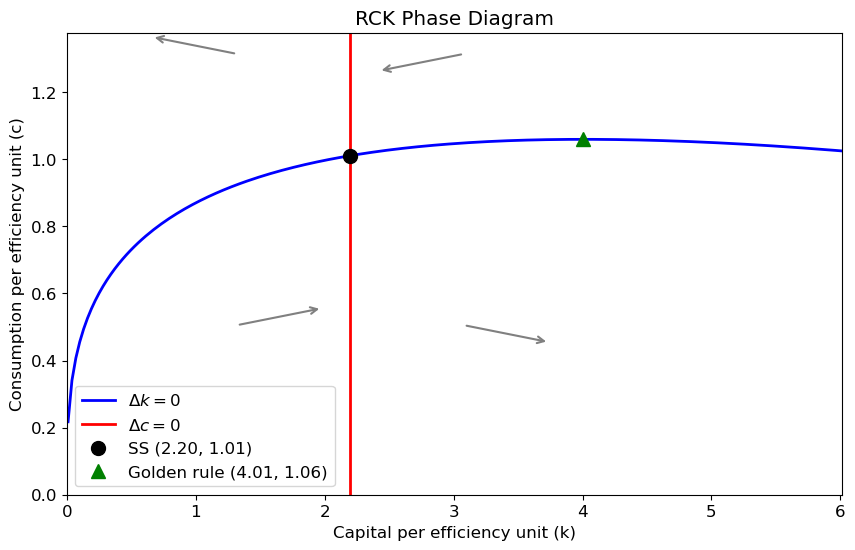

In [3]:
k_grid = np.linspace(0.01, k_gr * 1.5, 200)

# dk = 0 locus
c_dk_zero = f(k_grid) + (1 - delta) * k_grid - (1 + g) * (1 + n) * k_grid

fig, ax = plt.subplots()
ax.plot(k_grid, c_dk_zero, "b-", linewidth=2, label=r"$\Delta k = 0$")
ax.axvline(k_ss, color="r", linewidth=2, label=r"$\Delta c = 0$")
ax.plot(k_ss, c_ss, "ko", markersize=10, zorder=5, label=f"SS ({k_ss:.2f}, {c_ss:.2f})")
ax.plot(k_gr, c_gr, "g^", markersize=10, label=f"Golden rule ({k_gr:.2f}, {c_gr:.2f})")

# Direction arrows
for k_val, c_val in [(k_ss * 0.6, c_ss * 0.5), (k_ss * 1.4, c_ss * 0.5),
                      (k_ss * 0.6, c_ss * 1.3), (k_ss * 1.4, c_ss * 1.3)]:
    dk = (f(k_val) + (1 - delta) * k_val - c_val) / ((1 + g) * (1 + n)) - k_val
    R_val = f_prime(k_val) + 1 - delta
    dc = c_val * ((beta * R_val) ** (1 / rho) / ((1 + g) * (1 + n) ** (1 / rho)) - 1)
    scale_k = 0.3 * k_ss
    scale_c = 0.05 * c_ss
    ax.annotate("", xy=(k_val + scale_k * np.sign(dk), c_val + scale_c * np.sign(dc)),
                xytext=(k_val, c_val),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

ax.set_xlabel("Capital per efficiency unit (k)")
ax.set_ylabel("Consumption per efficiency unit (c)")
ax.set_title("RCK Phase Diagram")
ax.legend()
ax.set_xlim(0, k_gr * 1.5)
ax.set_ylim(0, c_gr * 1.3)
plt.show()

## Transition Dynamics (Shooting Method)

In [4]:
def simulate_rck(c0, k0, T):
    """Forward-simulate the RCK model from (k0, c0)."""
    k = np.zeros(T)
    c = np.zeros(T)
    k[0] = k0
    c[0] = c0

    for t in range(T - 1):
        k[t+1] = (f(k[t]) + (1 - delta) * k[t] - c[t]) / ((1 + g) * (1 + n))
        R = f_prime(k[t+1]) + 1 - delta
        c[t+1] = c[t] * (beta * R) ** (1 / rho) / ((1 + g) * (1 + n) ** (1 / rho))
        if k[t+1] <= 0 or c[t+1] <= 0:
            return None
    return k, c

T_sim = 80
k0 = 0.5 * k_ss

# Bisect on initial consumption to find the saddle path
c_lo, c_hi = 0.01, f(k0) + (1 - delta) * k0
for _ in range(60):
    c_mid = (c_lo + c_hi) / 2
    result = simulate_rck(c_mid, k0, T_sim)
    if result is None or result[0][-1] < k_ss:
        c_hi = c_mid  # consuming too much
    else:
        c_lo = c_mid

k_path, c_path = simulate_rck((c_lo + c_hi) / 2, k0, T_sim)
y_path = f(k_path)

C:\Users\msant\AppData\Local\Temp\ipykernel_12784\21173744.py:13: RuntimeWarning: invalid value encountered in scalar power
  return alpha * k ** (alpha - 1)


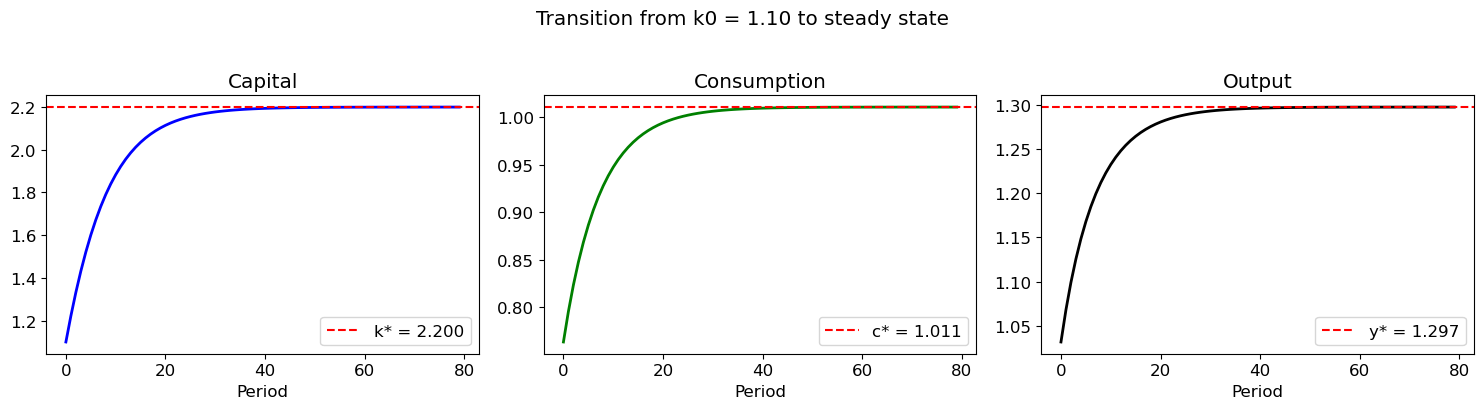

Consumption jumps to c0 = 0.7634 (SS is 1.0107)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_path, "b-", linewidth=2)
axes[0].axhline(k_ss, color="r", linestyle="--", label=f"k* = {k_ss:.3f}")
axes[0].set_title("Capital")
axes[0].set_xlabel("Period")
axes[0].legend()

axes[1].plot(c_path, "g-", linewidth=2)
axes[1].axhline(c_ss, color="r", linestyle="--", label=f"c* = {c_ss:.3f}")
axes[1].set_title("Consumption")
axes[1].set_xlabel("Period")
axes[1].legend()

axes[2].plot(y_path, "k-", linewidth=2)
axes[2].axhline(y_ss, color="r", linestyle="--", label=f"y* = {y_ss:.3f}")
axes[2].set_title("Output")
axes[2].set_xlabel("Period")
axes[2].legend()

plt.suptitle(f"Transition from k0 = {k0:.2f} to steady state", y=1.02)
plt.tight_layout()
plt.show()

print(f"Consumption jumps to c0 = {c_path[0]:.4f} (SS is {c_ss:.4f})")

## Your Project

In groups of three, pick one extension from the list below (or propose your own) and develop it within this notebook. This notebook is your paper and your deliverable. There is no separate report to write: the markdown cells are the written analysis, and the code cells are the implementation.

Your notebook should run from top to bottom without errors. A project that works, produces a clear result, and explains it well will score higher than an ambitious project that does not run.

**Notebook structure** (use markdown cells for the written parts):

1. **Introduction**: State the research question, explain why it matters, and summarize your approach and main findings.
2. **Literature review**: Which models and results from the course does your extension build on? What has been done before? Discuss 3-5 specific papers or course chapters.
3. **Model**: Present the modified equations. Define all new notation. Explain what changed relative to the baseline above and why your assumptions are needed.
4. **Methodology**: Describe calibration choices and any changes to the solution method. Justify parameter values.
5. **Results**: Figures, tables, and statistics that answer your question. Compare the baseline to your extension with specific numbers. Include sensitivity analysis or robustness checks.
6. **Conclusion**: Summarize the main findings, discuss limitations, and identify concrete directions for future work.

Each group also delivers a 10-minute in-class presentation with 5 minutes for questions.

**Due:** May 5, 2026. Submit the notebook (.ipynb) to Canvas. See the full project description and rubric for grading details (Code and Correctness 25, Written Analysis 25, Presentation 20, Creativity and Depth 20, Notebook Quality 10).

## Extension Ideas

The shooting method above works for any deterministic extension. For stochastic extensions, you can adapt the Blanchard-Kahn solver from the RBC notebook by log-linearizing the RCK Euler equation around the steady state.

- **Interest rate dynamics along the transition**: compute the SDF $M_{t+1} = \beta(c_{t+1}/c_t)^{-\rho} / (1+g)^\rho$ at each period from the shooting output. The interest rate starts high (capital is scarce) and falls toward the steady-state value $R^* = (1+g)^\rho(1+n)/\beta$. Compare to the C-CAPM pricing kernel from the asset pricing chapter.
- **Adjustment costs and $q$-theory**: add $\Phi(I/K) \cdot K$ to the resource constraint, following the q-Ramsey model from the growth chapter. The phase diagram gains a second dynamic variable $q$, and the saddle path determines the initial jump in $q$ after a policy shock (as in your assignment).
- **Tax policy**: introduce a corporate income tax $\tau$ and investment tax credit. The steady-state capital stock depends on the Hall-Jorgenson user cost of capital from the investment chapter; a permanent ITC shifts the $\Delta q = 0$ locus.
- **Government spending**: add $G_t$ financed by lump-sum taxes, following the RCK-with-government model from the growth chapter. The shooting method still applies; trace out the transition when $G$ jumps permanently.
- **Decentralization**: solve the competitive equilibrium and verify it matches the planner's solution, as in the Decentralizing RCK chapter. Then introduce a learning-by-doing externality (Romer, 1986) and show where the planner's and market solutions diverge.
- **Stochastic RCK**: add productivity shocks $a_t$ to the production function. The shooting method no longer works because the future is uncertain. Log-linearize the Euler and resource constraints around the steady state and apply the Blanchard-Kahn eigenvalue decomposition from the RBC notebook. This bridges the two starter notebooks. Note: the log-linearization and Blanchard-Kahn method used in the RBC notebook go beyond the lecture notes; you will need to study that notebook's solver before adapting it here.

---

*The cells above (through the shooting-method simulation) were provided as course starter code establishing the baseline RCK model. My project — extending the model to include government spending — begins below.*

---

# RCK Model with Government Spending

## 1. Introduction

The Ramsey–Cass–Koopmans (RCK) model is the workhorse environment for analyzing how fiscal policy reshapes equilibrium outcomes when households save optimally. Its analytical value derives from a single modeling choice: rather than fix the saving rate exogenously, as in the Solow model, the RCK framework lets a forward-looking representative agent choose the path of consumption to maximize discounted CRRA utility under a neoclassical production technology. The implication for policy analysis is direct. In the Solow setting, taxes and government spending rescale flows that no agent has chosen, so welfare claims have no anchor. In the RCK setting, every fiscal instrument perturbs an optimization the household is actively performing, and the welfare consequences of intervention can be quantified along the entire equilibrium path.

The framework's usefulness for policy analysis hinges on three interlocking features of its equilibrium structure. First, equilibrium is determinate. The joint dynamics of capital kt and consumption ct admit a unique saddle path through any admissible initial capital stock k0, and consumption must jump onto this path at t=0 for the transversality condition to hold. The saddle-path property pins down the entire equilibrium trajectory from k0 alone, leaving no indeterminacy for policy analysis to obscure. Second, the model produces nontrivial transition dynamics off the steady state: the time path of capital, consumption, and the real interest rate from k0 toward (k*, c*) is the natural object on which to measure the short- and medium-run effects of any shock or policy change. Third, the steady state itself yields a benchmark for long-run comparative statics — shifts in (k*, c*) and in the implied long-run interest rate that follows from changes in deep parameters or in the policy environment. Saddle path, transition, and steady state together form a self-contained toolkit. A fiscal intervention can reshape the equilibrium through any of these three channels: by perturbing the saddle path, by altering the speed and shape of the transition, or by shifting the long-run targets to which the economy converges.

The baseline RCK model abstracts from one feature that no real economy lacks: a government. Fiscal policy operates through distortionary taxation, public-goods provision, and the timing of government purchases, and each channel alters the household's optimization in a way the baseline cannot capture. A substantial literature extends the canonical RCK environment to incorporate fiscal instruments, but the bulk of this work treats government spending as exogenous and focuses on its steady-state implications. The interaction between endogenously chosen public spending and the intertemporal margin of household choice has received less direct attention, and the conditions under which utility-yielding government spending leaves the transition path of the economy undisturbed have not been characterized within this benchmark setting. We establish such a condition. Under separable preferences and lump-sum financing, utility-yielding government spending affects only the intratemporal allocation of resources between private and public consumption; the intertemporal margin governing how the consumption bundle is allocated across periods is unchanged. We refer to this as an intertemporal neutrality result for utility-yielding government spending. Although the result follows mechanically from separability once derived, it is not obvious ex ante that endowing the planner with a non-trivial taste for public goods would leave the saddle path, the transition speed, and the path of the real interest rate undisturbed for every value of the preference weight. Section 2 places this contribution in the existing literature on government and growth.

## 2. Literature Review

In the basic setup of the RCK model with government, we assume exogenous determination of a lump-sum tax, government spending equal to said tax, and no utility from government spending. This changes the household budget constraint to ȧ𝑡 = 𝑟𝑡𝑎𝑡 + 𝑤𝑡 − 𝑐𝑡 − 𝑇. In this framework, steady-state capital remains unchanged whereas steady-state consumption decreases because, “the social planner divides total net output net output between consumption and government spending,” (Carroll and Lujan). With the given assumptions, this essentially makes the entire economy "worse off" by diverting resource from utility-providing consumption to “wasteful” government spending.

Romer (2012) reinforces this point that the ċ = 0 locus is unaffected and the ḳ = 0 locus is shifted downwards by the amount of government purchases (p. 72). This analysis also differentiates between permanent and temporary tax increases, finding that the former has a lesser impact on consumption since households choose to pay taxes out of savings instead (ostensibly temporarily lowering capital). Also relevant for our purposes, Romer notes that we see similar results to the RCK dynamics even if, “utility equals the sum of utility from private consumption and utility from government-provided goods” (p. 71). This informs the structure of our model and suggests that we will see similar steady-state dynamics even when government spending is endogenous.

Barro (1990) also analyzes the impact of government on growth, citing the RCK model as the basic framework. This paper takes a few different approaches, first analyzing public spending as a factor of production, then incorporating public goods into utility (though with a Cobb-Douglas framework alongside private consumption), and finally supposing a self-interested government agent rather than a benevolent social planner. Through these approaches, Barro does endogenize the selection of government spending based on growth path and utility optimization, the latter of which we seek to do in our model.

References:

Barro, R. J. (1988). Government spending in a simple model of endogenous growth (NBER Working Paper No. 2588). National Bureau of Economic Research. https://doi.org/10.3386/w2588

Carroll, Christopher D. and Alan E. Lujan Solis. A Gentle Introduction to Intertemporal Choice. Johns Hopkins University. https://github.com/jhu-econ/intertemporal-choice

Romer, D. (2012). Advanced macroeconomics (4th ed.). McGraw-Hill.

## 3. Model

Add a government that levies lump-sum taxes $T_t$ and spends $G_t$ per period, with $T_t$ = $G_t$. Government spending yields CRRA utility:

$$v(G_t) = \phi \frac{G_t^{1-\rho}}{1-\rho}$$

where $\phi > 0$ is the relative weight the social planner places on public goods utility versus private consumption utility. 

* $\phi < 1$ $\implies$ private consumption is weighted more heavily than public goods consumption
* $\phi = 1$ $\implies$ the two are weighted equally
* $\phi > 1$ $\implies$ public goods consumption is weighted more heavily than private consumption

The social planner maximizes the discounted sum of utility from both private consumption and public spending:

$$\max_{\{c_t, G_t, k_{t+1}\}} \sum_{t=0}^{\infty} \beta^t \left[ \frac{c_t^{1-\rho}}{1-\rho} + \phi \frac{G_t^{1-\rho}}{1-\rho} \right]$$

subject to the resource constraint:

$$k_{t+1} = \frac{f(k_t) + (1-\delta)k_t - c_t - G_t}{(1+g)(1+n)}$$

Taking FOCs, we get:

$$u'(c_t) = v'(G_t) \implies G_t = \phi^{1/\rho} c_t$$

Substituting $G_t = \phi^{1/\rho} c_t$ into the law of motion for capital:

$$k_{t+1} = \frac{f(k_t) + (1-\delta)k_t - c_t - \phi^{1/\rho} c_t}{(1+g)(1+n)} = \frac{f(k_t) + (1-\delta)k_t - \psi c_t}{(1+g)(1+n)}$$

where $\psi c_t = c_t(1 + \phi^{1/\rho})$ represents the aggregate consumption bundle of private and public goods.

Since the static optimality condition $u'(c_t)$ = $v'(G_t)$ holds in every period, we can write the Euler equation in terms of the aggregate consumption bundle $\psi c_t$:

$$\frac{\psi c_{t+1}}{\psi c_t} = \frac{\left(\beta(f'(k_{t+1}) + 1 - \delta)\right)^{1/\rho}}{(1+g)(1+n)^{1/\rho}} = \frac{c_{t+1}}{c_t}$$

The Euler equation is exactly the same as in the baseline model. The planner's intertemporal tradeoff between today and tomorrow is unaffected by public spending. The static optimality condition handles the split between $c_t$ and $G_t$ at each period, so the dynamic problem is the same as the baseline RCK Euler equation.

As before, at steady state $f'(k^*) + 1 - \delta = (1+g)^\rho (1+n)/\beta$, so $k^*$ is unchanged from the baseline. Private consumption and government spending at steady state are:

$c^* = \frac{f(k^*) + (1-\delta)k^* - (1+g)(1+n)k^*}{\psi}$

$G^* = \phi^{1/\rho} c^*$

## 4. Methodology

### 4.1 Calibration and Steady State

In [7]:
# Parameters kept the same from the baseline model
alpha = 0.33    # capital share
beta = 0.96     # discount factor (on per-capita utility)
rho = 2.0       # CRRA coefficient
delta = 0.10    # depreciation
n = 0.01        # population growth
g = 0.02        # productivity growth

# New parameters
phi = 1         # equal weighting of public and private goods
psi = 1 + phi ** (1 / rho)

def f(k):
    return k ** alpha

def f_prime(k):
    return alpha * k ** (alpha - 1)

# Steady state capital equation the same as the baseline model
# Steady state: f'(k*) + 1 - delta = (1+g)^rho * (1+n) / beta
R_ss_G = (1 + g) ** rho * (1 + n) / beta
mpk_ss_G = R_ss - 1 + delta
k_ss_G = (alpha / mpk_ss) ** (1 / (1 - alpha))
y_ss_G = f(k_ss)
 
# Resource constraint at SS with government spending: k = (f(k) + (1-delta)*k - psi*c) / ((1+g)*(1+n))
# => c_ss = [f(k_ss) + (1-delta)*k_ss - (1+g)*(1+n)*k_ss] / psi
c_ss_G = (f(k_ss) + (1 - delta) * k_ss - (1 + g) * (1 + n) * k_ss) / psi
# Steady state government spending: G_ss = phi^(1/rho) * c_ss
G_ss = phi ** (1 / rho) * c_ss_G

# Golden rule: f'(k_gr) = (1+g)*(1+n) - 1 + delta
# Does not include any of the new parameters or government spending, so remains the same
mpk_gr = (1 + g) * (1 + n) - 1 + delta
k_gr = (alpha / mpk_gr) ** (1 / (1 - alpha))
c_gr = f(k_gr) + (1 - delta) * k_gr - (1 + g) * (1 + n) * k_gr

print(f"Baseline steady state:    k* = {k_ss:.4f}, c* = {c_ss:.4f}, y* = {y_ss:.4f}")
print(f"Government model SS:      k* = {k_ss_G:.4f}, c* = {c_ss_G:.4f}, G* = {G_ss:.4f}, y* = {y_ss_G:.4f}")
print(f"Golden rule:              k_gr = {k_gr:.4f}, c_gr = {c_gr:.4f}")
print(f"Dynamic efficiency:       k* < k_gr is {k_ss_G < k_gr}")

Baseline steady state:    k* = 2.1998, c* = 1.0107, y* = 1.2971
Government model SS:      k* = 2.1998, c* = 0.5054, G* = 0.5054, y* = 1.2971
Golden rule:              k_gr = 4.0072, c_gr = 1.0593
Dynamic efficiency:       k* < k_gr is True


## 4.2 Phase Diagram

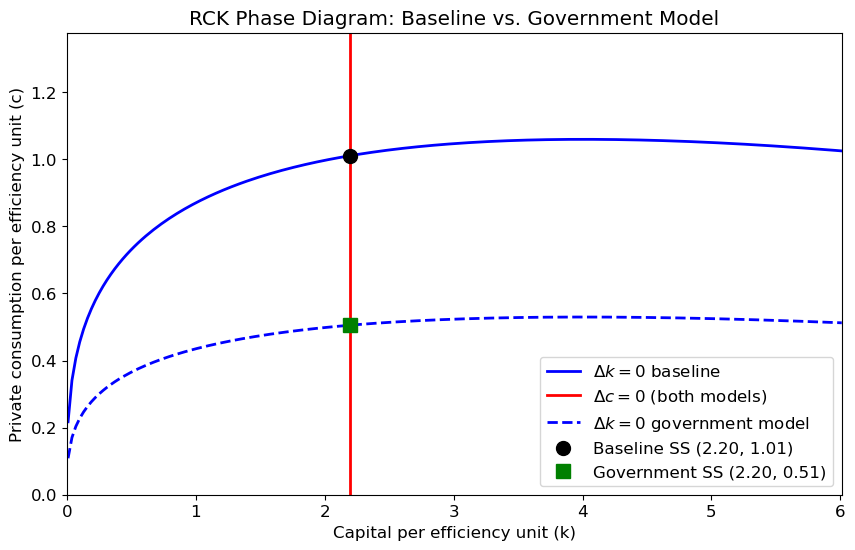

In [8]:
k_grid = np.linspace(0.01, k_gr * 1.5, 200)

# Baseline dk = 0 locus
c_dk_zero_baseline = f(k_grid) + (1 - delta) * k_grid - (1 + g) * (1 + n) * k_grid

# Government model dk = 0 locus: divide by psi
c_dk_zero_G = c_dk_zero_baseline / psi

fig, ax = plt.subplots()

# Baseline loci
ax.plot(k_grid, c_dk_zero_baseline, "b-", linewidth=2, label=r"$\Delta k = 0$ baseline")
ax.axvline(k_ss, color="r", linewidth=2, label=r"$\Delta c = 0$ (both models)")

# Government model loci
ax.plot(k_grid, c_dk_zero_G, "b--", linewidth=2, label=r"$\Delta k = 0$ government model")

# Steady state points
ax.plot(k_ss, c_ss, "ko", markersize=10, zorder=5, label=f"Baseline SS ({k_ss:.2f}, {c_ss:.2f})")
ax.plot(k_ss_G, c_ss_G, "gs", markersize=10, zorder=5, label=f"Government SS ({k_ss_G:.2f}, {c_ss_G:.2f})")

ax.set_xlabel("Capital per efficiency unit (k)")
ax.set_ylabel("Private consumption per efficiency unit (c)")
ax.set_title("RCK Phase Diagram: Baseline vs. Government Model")
ax.legend()
ax.set_xlim(0, k_gr * 1.5)
ax.set_ylim(0, max(c_dk_zero_baseline) * 1.3)
plt.show()

Steady state capital remains unchanged, consumption decreases exactly by the amount of government spending. 

## 5. Results

### 5.1 Transition Dynamics (Shooting Method)

In [ ]:
def simulate_rck_G(c0, k0, T, psi):
    k = np.zeros(T)
    c = np.zeros(T)
    G = np.zeros(T)
    k[0] = k0
    c[0] = c0
    G[0] = phi ** (1 / rho) * c0                # Follows directly from c0, not selected independently


## Replace c[t] from baseline model with psi*c[t]
    for t in range(T - 1):
        k[t+1] = (f(k[t]) + (1 - delta) * k[t] - psi * c[t]) / ((1 + g) * (1 + n))
        R = f_prime(k[t+1]) + 1 - delta
        c[t+1] = c[t] * (beta * R) ** (1 / rho) / ((1 + g) * (1 + n) ** (1 / rho))
        G[t+1] = phi ** (1 / rho) * c[t+1]      # Include transition dynamics for G
        if k[t+1] <= 0 or c[t+1] <= 0:
            return None
    return k, c, G

T_sim = 80
k0 = 0.5 * k_ss_G

# Bisection on initial consumption to find the saddle path
c_lo, c_hi = 0.01, f(k0) + (1 - delta) * k0
for _ in range(60):
    c_mid = (c_lo + c_hi) / 2
    result = simulate_rck_G(c_mid, k0, T_sim, psi)
    if result is None or result[0][-1] < k_ss_G:
        c_hi = c_mid
    else:
        c_lo = c_mid

k_path_G, c_path_G, G_path = simulate_rck_G((c_lo + c_hi) / 2, k0, T_sim, psi)
y_path_G = f(k_path_G)

C:\Users\msant\AppData\Local\Temp\ipykernel_12784\1486866744.py:17: RuntimeWarning: invalid value encountered in scalar power
  return alpha * k ** (alpha - 1)


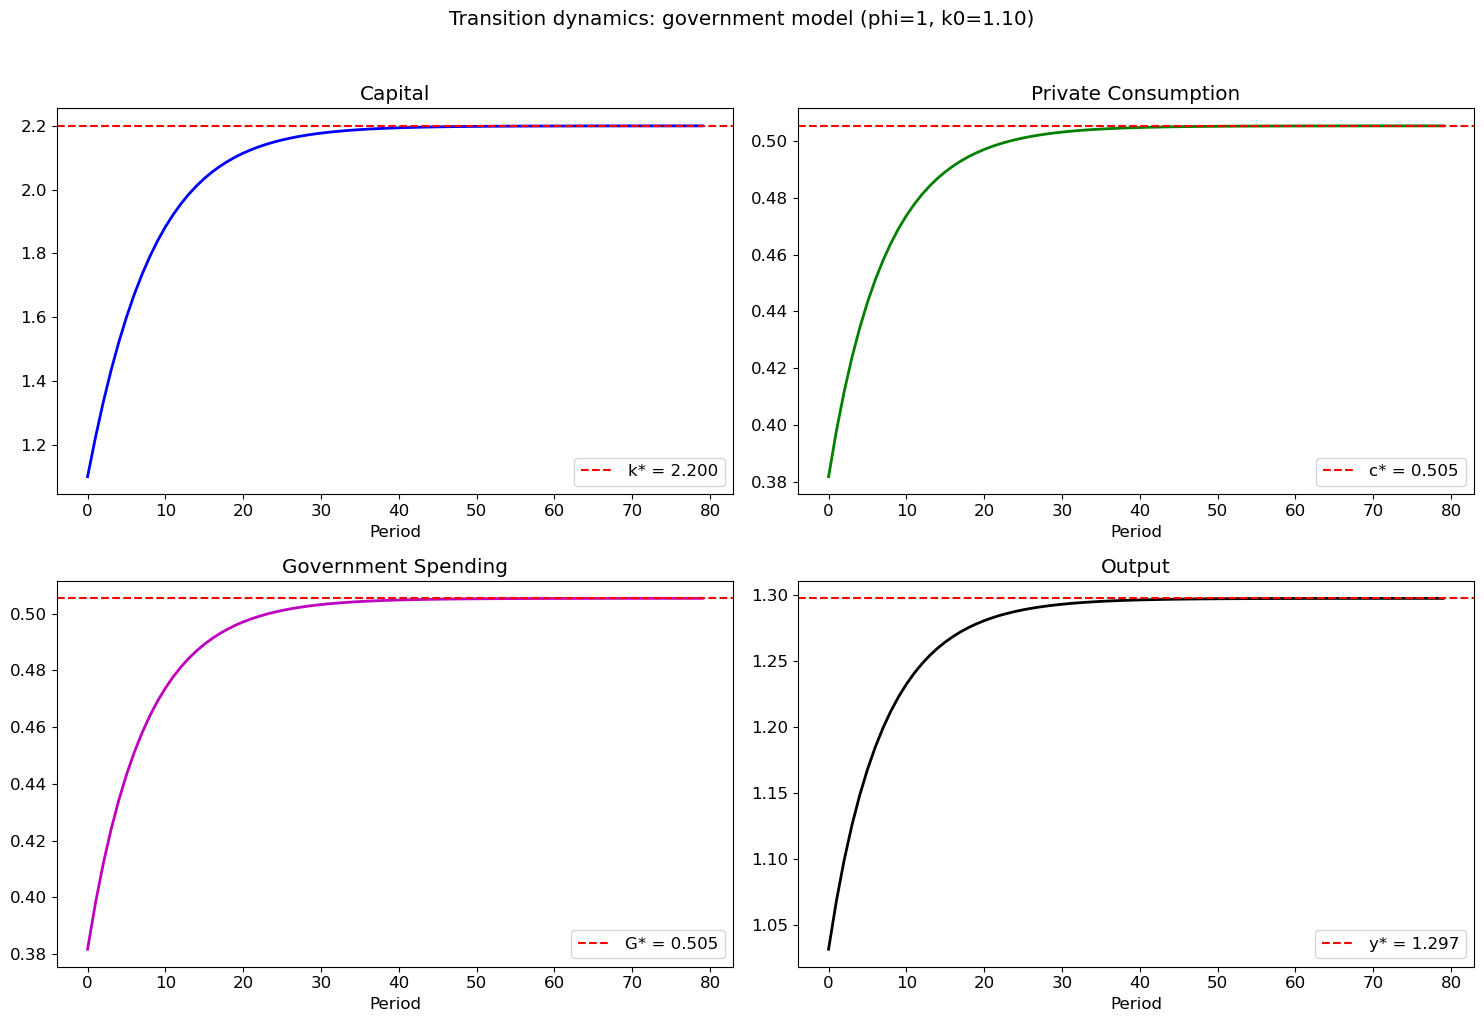

Initial values: c0 = 0.3817, G0 = 0.3817
Steady state:   c* = 0.5054, G* = 0.5054


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(k_path_G, "b-", linewidth=2)
axes[0, 0].axhline(k_ss_G, color="r", linestyle="--", label=f"k* = {k_ss_G:.3f}")
axes[0, 0].set_title("Capital")
axes[0, 0].set_xlabel("Period")
axes[0, 0].legend()

axes[0, 1].plot(c_path_G, "g-", linewidth=2)
axes[0, 1].axhline(c_ss_G, color="r", linestyle="--", label=f"c* = {c_ss_G:.3f}")
axes[0, 1].set_title("Private Consumption")
axes[0, 1].set_xlabel("Period")
axes[0, 1].legend()

axes[1, 0].plot(G_path, "m-", linewidth=2)
axes[1, 0].axhline(G_ss, color="r", linestyle="--", label=f"G* = {G_ss:.3f}")
axes[1, 0].set_title("Government Spending")
axes[1, 0].set_xlabel("Period")
axes[1, 0].legend()

axes[1, 1].plot(y_path_G, "k-", linewidth=2)
axes[1, 1].axhline(y_ss_G, color="r", linestyle="--", label=f"y* = {y_ss_G:.3f}")
axes[1, 1].set_title("Output")
axes[1, 1].set_xlabel("Period")
axes[1, 1].legend()

plt.suptitle(f"Transition dynamics: government model (phi={phi}, k0={k0:.2f})", y=1.02)
plt.tight_layout()
plt.show()

print(f"Initial values: c0 = {c_path_G[0]:.4f}, G0 = {G_path[0]:.4f}")
print(f"Steady state:   c* = {c_ss_G:.4f}, G* = {G_ss:.4f}")

### 5.2 Maximizing Societal Welfare

In the baseline RCK model, government spending financed by lump-sum taxation crowds out private consumption in steady state but leaves the capital stock unchanged: $c^* < c^*_{baseline}$ while $k^*$ is identical across both models. A planner maximizing private consumption alone would therefore set $G = 0$.

However, in our model, the social planner is trying to maximize societal welfare. Resources utilized for consumption are split between private goods through individuals and public goods through taxation and government spending. Public goods like infrastructure, defense, and public health all provide benefits which we earlier characterized with the CRRA value function $v(G_t) = \phi \frac{G_t^{1-\rho}}{1-\rho}$.

The preference weight $\phi$ determines the optimal split between private and public consumption.

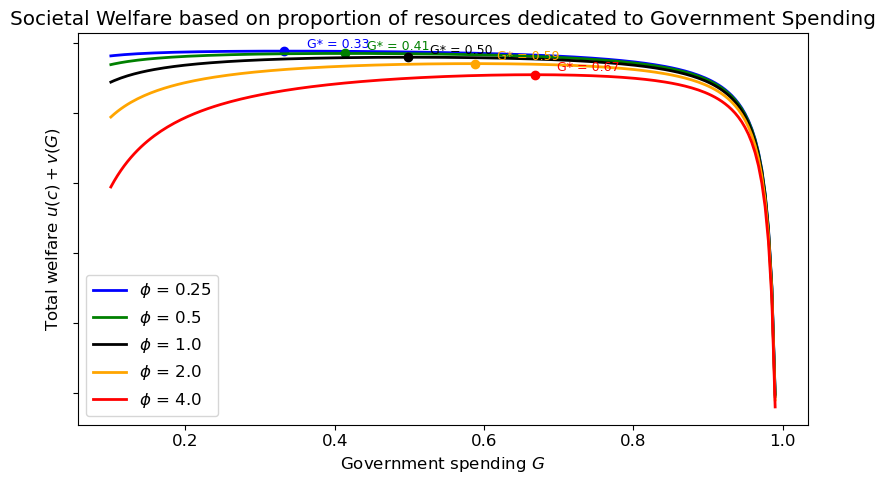

Optimal consumption splits by phi:

phi = 0.25 | optimal G* = 0.3326 | optimal c* = 0.6674
phi = 0.50 | optimal G* = 0.4131 | optimal c* = 0.5869
phi = 1.00 | optimal G* = 0.4980 | optimal c* = 0.5020
phi = 2.00 | optimal G* = 0.5875 | optimal c* = 0.4125
phi = 4.00 | optimal G* = 0.6680 | optimal c* = 0.3320


In [27]:
Y = 1.0
c_grid = np.linspace(0.01, 0.9, 200)
G_grid = Y - c_grid
phi_values = [0.25, 0.5, 1.0, 2.0, 4.0]
colors = ["blue", "green", "black", "orange", "red"]

fig, ax = plt.subplots(figsize=(8, 5))

for phi_i, color in zip(phi_values, colors):
    welfare_i = c_grid ** (1 - rho) / (1 - rho) + phi_i * G_grid ** (1 - rho) / (1 - rho)
    
    ax.plot(G_grid, welfare_i, color=color, linewidth=2, label=f"$\\phi$ = {phi_i}")
    
    # Find and label the max
    max_idx = np.argmax(welfare_i)
    ax.plot(G_grid[max_idx], welfare_i[max_idx], "o", color=color, markersize=6)
    ax.annotate(f"G* = {G_grid[max_idx]:.2f}", 
                xy=(G_grid[max_idx], welfare_i[max_idx]),
                xytext=(G_grid[max_idx] + 0.03, welfare_i[max_idx] + 1),
                fontsize=9, color=color)

ax.set_xlabel("Government spending $G$")
ax.set_ylabel("Total welfare $u(c) + v(G)$")
ax.set_title("Societal Welfare based on proportion of resources dedicated to Government Spending")
ax.yaxis.set_ticklabels([])
ax.legend()
plt.tight_layout()
plt.show()


print("Optimal consumption splits by phi:\n")
for phi_i, color in zip(phi_values, colors):
    welfare_i = c_grid ** (1 - rho) / (1 - rho) + phi_i * G_grid ** (1 - rho) / (1 - rho)
    max_idx = np.argmax(welfare_i)
    print(f"phi = {phi_i:.2f} | optimal G* = {G_grid[max_idx]:.4f} | optimal c* = {c_grid[max_idx]:.4f}")

The optimal proportion of spending on public goods varies based on the value of $\phi$ in an expected manner. The greater the value of $\phi$ (i.e. the higher the preference weight for public goods compared to private goods), the greater the optimal value of government spending, and conversely the lower the optimal value of private consumption. Importantly, for all values of $\phi > 0$, there is some value of $G^* > 0$ that optimizes societal welfare. Optimal government spending is never zero as long as there is some degree of relative preference for public goods.

### 5.3 Transition Dynamics with Varying $\phi$

In [ ]:
def simulate_rck_phi(c0, k0, T, psi, phi_i):
    k = np.zeros(T)
    c = np.zeros(T)
    G = np.zeros(T)
    k[0] = k0
    c[0] = c0
    G[0] = phi_i ** (1 / rho) * c0                

    for t in range(T - 1):
        k[t+1] = (f(k[t]) + (1 - delta) * k[t] - psi * c[t]) / ((1 + g) * (1 + n))
        R = f_prime(k[t+1]) + 1 - delta
        c[t+1] = c[t] * (beta * R) ** (1 / rho) / ((1 + g) * (1 + n) ** (1 / rho))
        G[t+1] = phi_i ** (1 / rho) * c[t+1]      # Include transition dynamics for G
        if k[t+1] <= 0 or c[t+1] <= 0:
            return None
    return k, c, G

C:\Users\msant\AppData\Local\Temp\ipykernel_12784\1486866744.py:17: RuntimeWarning: invalid value encountered in scalar power
  return alpha * k ** (alpha - 1)


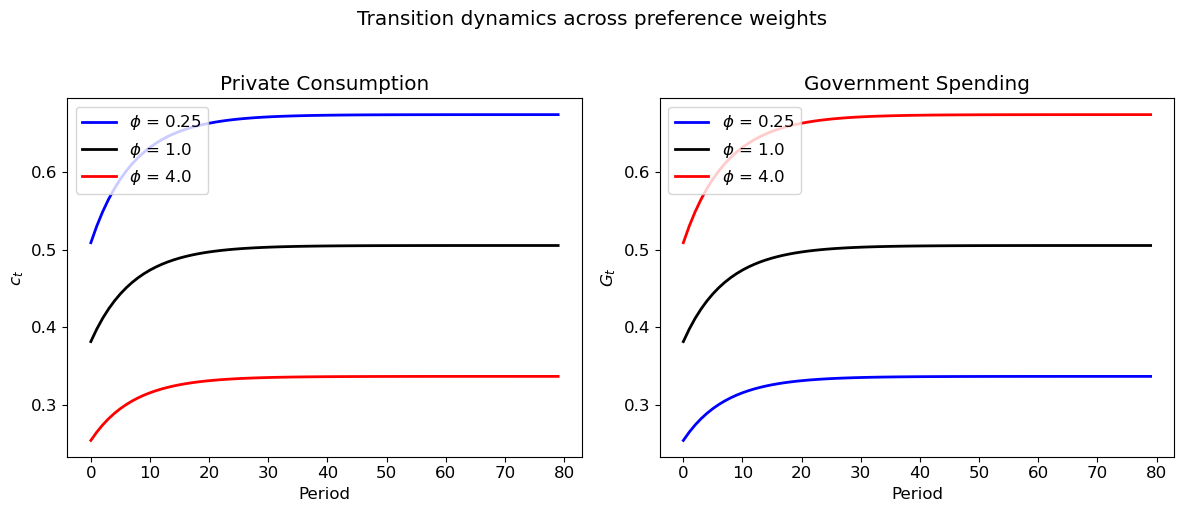

Transition dynamics summary:

phi = 0.25
  c: initial = 0.5089, steady state = 0.6738, converges at period 24 (within 1% of c*)
  G: initial = 0.2545, steady state = 0.3369, converges at period 24 (within 1% of G*)

phi = 1.00
  c: initial = 0.3817, steady state = 0.5054, converges at period 24 (within 1% of c*)
  G: initial = 0.3817, steady state = 0.5054, converges at period 24 (within 1% of G*)

phi = 4.00
  c: initial = 0.2545, steady state = 0.3369, converges at period 24 (within 1% of c*)
  G: initial = 0.5089, steady state = 0.6738, converges at period 24 (within 1% of G*)



In [37]:
phi_values_transition = [0.25, 1.0, 4.0]
colors_transition = ["blue", "black", "red"]

T_sim = 80
k0 = 0.5 * k_ss_G

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

paths = {}

for phi_i, color in zip(phi_values_transition, colors_transition):
    psi_i = 1 + phi_i ** (1 / rho)
    
    # Bisection for this phi
    c_lo, c_hi = 0.01, f(k0) + (1 - delta) * k0
    for _ in range(60):
        c_mid = (c_lo + c_hi) / 2
        result = simulate_rck_phi(c_mid, k0, T_sim, psi_i, phi_i)
        if result is None or result[0][-1] < k_ss_G:
            c_hi = c_mid
        else:
            c_lo = c_mid
    
    k_path_i, c_path_i, G_path_i = simulate_rck_phi((c_lo + c_hi) / 2, k0, T_sim, psi_i, phi_i)
    paths[phi_i] = (k_path_i, c_path_i, G_path_i)
    
    axes[0].plot(c_path_i, color=color, linewidth=2, label=f"$\\phi$ = {phi_i}")
    axes[1].plot(G_path_i, color=color, linewidth=2, label=f"$\\phi$ = {phi_i}")

axes[0].set_title("Private Consumption")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("$c_t$")
axes[0].legend()

axes[1].set_title("Government Spending")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("$G_t$")
axes[1].legend()

plt.suptitle("Transition dynamics across preference weights", y=1.02)
plt.tight_layout()
plt.show()

print("Transition dynamics summary:\n")
for phi_i in phi_values_transition:
    psi_i = 1 + phi_i ** (1 / rho)
    c_ss_i = (f(k_ss_G) + (1 - delta) * k_ss_G - (1 + g) * (1 + n) * k_ss_G) / psi_i
    G_ss_i = phi_i ** (1 / rho) * c_ss_i
    
    k_path_i, c_path_i, G_path_i = paths[phi_i]
    
    c_conv = next((t for t in range(T_sim) if abs(c_path_i[t] - c_ss_i) / c_ss_i < 0.01), None)
    G_conv = next((t for t in range(T_sim) if abs(G_path_i[t] - G_ss_i) / G_ss_i < 0.01), None)
    
    print(f"phi = {phi_i:.2f}")
    print(f"  c: initial = {c_path_i[0]:.4f}, steady state = {c_ss_i:.4f}, converges at period {c_conv} (within 1% of c*)")
    print(f"  G: initial = {G_path_i[0]:.4f}, steady state = {G_ss_i:.4f}, converges at period {G_conv} (within 1% of G*)")
    print()

Higher $\phi$ implies lower $c^*$ and higher $G^*$, reflecting the planner's stronger preference for public goods, but does not impact the transition dynamics. Consumption and government spending converge to their respective steady state values at the same rate regardless of $\phi$.

## 6. Conclusion

We set out to examine how utility-yielding government spending interacts with the intertemporal
optimization problem at the heart of the Ramsey-Cass-Koopmans model. The baseline RCK
framework, as we noted in the introduction, provides three interlocking tools for policy analysis:
a determinate saddle path, nontrivial transition dynamics, and a well-defined steady state. Our
central question was whether endowing the social planner with a preference for public goods
would reshape any of these objects. The answer, under our assumptions, is a qualified no.
We derived what we called an intertemporal neutrality result. When preferences over private
consumption and government spending are additively separable and both take the CRRA form
with identical curvature, the planner's first-order conditions collapse to a simple static rule
linking public and private consumption at every date. This rule, combined with lump-sum
financing, implies that the Euler equation governing the growth rate of consumption is identical
to the baseline model without government. The steady-state capital stock remains unchanged
across all values of the preference weight on public goods. What changes is purely intratemporal:
the split of resources between private and public consumption shifts with the parameter we
labeled phi, but the path of capital accumulation and the speed of convergence do not.
Our numerical results confirmed this logic. The phase diagram showed that introducing
government spending shifts the locus along which capital is stationary downward, but the locus
along which consumption is stationary remains a vertical line at the same steady-state capital as
in the baseline. Transition dynamics simulated via the shooting method revealed that economies
starting from the same initial capital stock converge to steady state at the same rate regardless of
whether phi equals 0.25, 1, or 4. Higher phi simply reallocates resources toward public goods at
every point along the transition, without altering the transition itself.
We also explored the welfare implications of varying phi. For any positive weight on public
goods, the planner finds it optimal to allocate a strictly positive share of output to government
spending. The optimal split depends on phi in the expected direction: stronger preferences for
public goods imply higher steady-state government spending and lower private consumption.
This result, while intuitive, underscores that the neutrality we establish is about dynamics, not
about levels. The composition of the consumption bundle matters for welfare even when the time
path of capital does not change.

Several limitations deserve mention. First, we maintained the assumption of lump-sum taxation
throughout. Real-world fiscal policy relies heavily on distortionary taxes, and introducing
income or capital taxation would break the neutrality result by driving a wedge between the
private and social returns to saving. Second, we assumed that private and public consumption
enter utility separably and with the same degree of curvature. If the two goods were
complements or substitutes, or if risk aversion differed across the two, the static optimality
condition would no longer yield a constant ratio between c and G, and the Euler equation would
inherit terms involving government spending. Third, we treated the preference weight phi as a
fixed parameter rather than as a policy choice. A richer model might allow the government to
choose phi endogenously, subject to political or institutional constraints, which would open new
channels through which fiscal policy could affect dynamics.
These limitations point toward natural extensions. One could introduce distortionary taxation and
ask how the neutrality result breaks down as the tax wedge increases. Alternatively, one could
relax separability and characterize how complementarity or substitutability between public and
private goods alters the transition path. A third direction would embed the model in a political-
economy framework where phi itself is determined by voting or lobbying, linking the preference
weight to deeper features of the economy.
In sum, we have shown that utility-yielding government spending, under separable CRRA
preferences and lump-sum financing, is intertemporally neutral in the RCK framework. The
planner's taste for public goods reshapes the composition of output at every date but leaves the
saddle path, the convergence speed, and the steady-state capital stock undisturbed. This result
clarifies the channels through which fiscal policy operates in the workhorse model of optimal
growth and provides a benchmark against which richer specifications can be compared.